### Libraries

In [1]:
import pandas as pd
import pandas as pd
import tensorflow as tf

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import accuracy_score, auc, roc_curve
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model

### Setup

In [4]:
df = pd.read_csv('C:\\Users\\User\\ODL_Labs\\Assignment\\data\\preprocessed_churn_dataset.csv')

In [ ]:
train_df = pd.read_csv('C:\\Users\\User\\ODL_Labs\\Assignment\\data\\train_churn_dataset.csv')
val_df = pd.read_csv('C:\\Users\\User\\ODL_Labs\\Assignment\\data\\val_churn_dataset.csv')
test_df = pd.read_csv('C:\\Users\\User\\ODL_Labs\\Assignment\\data\\test_churn_dataset.csv')

In [ ]:
X_train = train_df.drop(columns=['Churn'])
y_train = train_df['Churn']

In [ ]:
X_val = val_df.drop(columns=['Churn'])
y_val = val_df['Churn']

In [ ]:
X_test = test_df.drop(columns=['Churn'])
y_test = test_df['Churn']

In [ ]:
print("Training set size:", len(X_train))
print("Validation set size:", len(X_val))
print("Test set size:", len(X_test))

# Distribution of labels in the training set
train_labels = y_train.values

print("\nTraining set label distribution:")
print(pd.Series(train_labels).value_counts(normalize=True))

### Model Training

In [10]:
input_dim = X_train.shape[1]

inputs = Input(shape=(input_dim,))

# -----------------
# Wide branch
# -----------------
wide = Dense(
    1,
    activation='linear'
)(inputs)

# -----------------
# Deep branch
# -----------------
deep = Dense(128, activation='relu')(inputs)
deep = Dropout(0.3)(deep)

deep = Dense(64, activation='relu')(deep)
deep = Dropout(0.3)(deep)

deep = Dense(32, activation='relu')(deep)

# -----------------
# Combine
# -----------------
combined = Concatenate()([wide, deep])

outputs = Dense(
    1,
    activation='sigmoid'
)(combined)

model = Model(inputs=inputs, outputs=outputs)

In [11]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [12]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=30,                      # Train for 30 epochs
    batch_size=32,                  # 32 samples per batch
    validation_data=(X_val, y_val), # Monitor on validation set
    verbose=1                       # Show progress bar
)

Epoch 1/30
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 12s 982us/step - accuracy: 0.9190 - loss: 0.2437 - val_accuracy: 0.9297 - val_loss: 0.2140
Epoch 2/30
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.9299 - loss: 0.2138 - val_accuracy: 0.9300 - val_loss: 0.2102
Epoch 3/30
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy: 0.9308 - loss: 0.2091 - val_accuracy: 0.9308 - val_loss: 0.2046
Epoch 4/30
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - accuracy: 0.9312 - loss: 0.2072 - val_accuracy: 0.9309 - val_loss: 0.2037
Epoch 5/30
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy: 0.9316 - loss: 0.2052 - val_accuracy: 0.9284 - val_loss: 0.2087
Epoch 6/30
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy: 0.9318 - loss: 0.2045 - val_accuracy: 0.9321 - val_loss: 0.2007
Epoch 7/30
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 11s 964us/step - accuracy: 0.9322 - loss: 0.2030 - val_accuracy: 0.9322 - val_loss: 0.1996
Epoch 8/30
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 10s 934us/step - accu

### Model Evaluation

In [13]:
# Test the model on the test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

2369/2369 ━━━━━━━━━━━━━━━━━━━━ 1s 419us/step


In [ ]:
# Classification report
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

accuracy = accuracy_score(y_test, y_pred)
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

print(f"CLASSIFICATION REPORT:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

CLASSIFICATION REPORT:
Train Ratio: 0.70, Validation Ratio: 0.15, Test Ratio: 0.15

Accuracy: 0.9345878254443726
Precision: 0.8975369458128079
Recall: 0.9958886855676228
F1-score: 0.9441584336874359


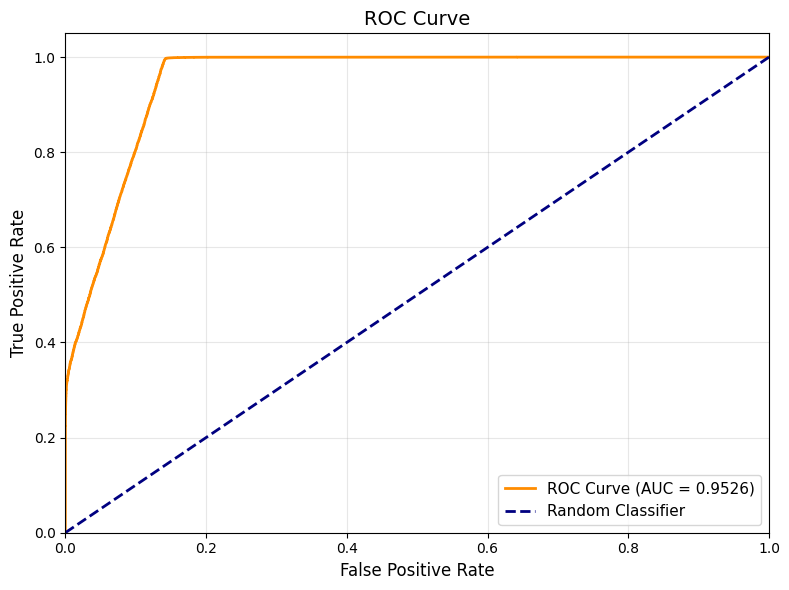

AUC Score: 0.9526


In [15]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('roc_auc_curve.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

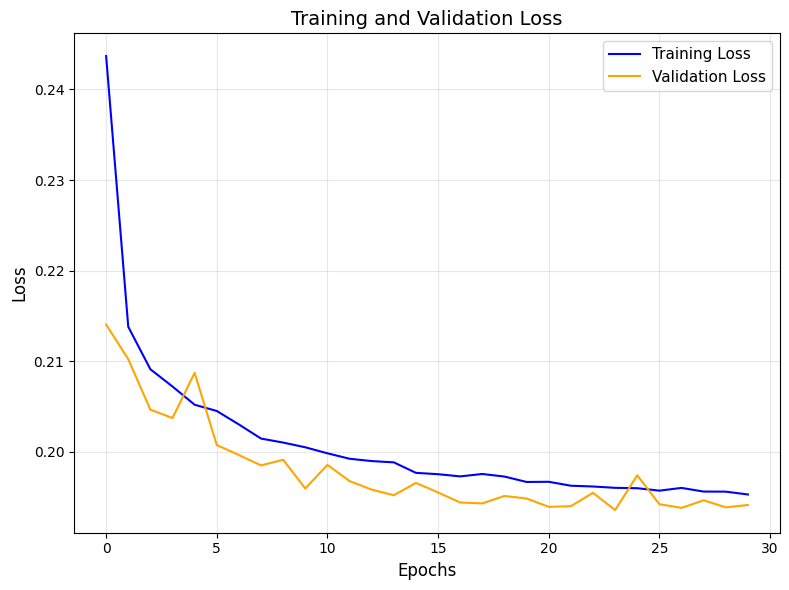

In [16]:
# Training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()


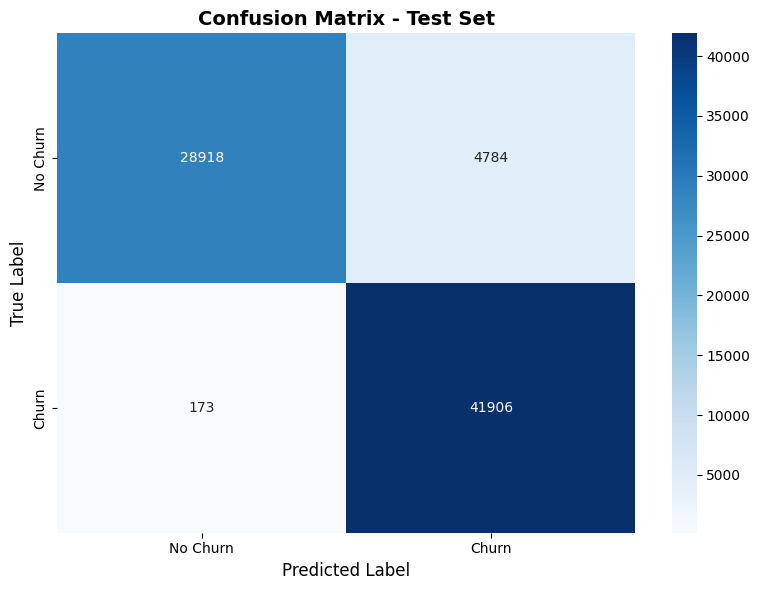

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
 
# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,  # Show numbers in cells
    fmt='d',     # Format as integers
    cmap='Blues',  # Color palette
    cbar=True,   # Show color bar
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)
 
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()